In [20]:
from detoxify import Detoxify as detox
import pandas as pd
import torch
import seaborn as sns

In [2]:
import os
from dotenv import load_dotenv

load_dotenv() 

token = os.getenv("HF_TOKEN")

In [3]:
datacrime = pd.read_csv("./crime_tweets_in_portuguese.csv")
datacrime

,id,text,INSULT,IDENTITY_ATTACK,SEVERE_TOXICITY,THREAT,PROFANITY,TOXICITY,POSITIVE,NEUTRAL,...,ASSALTO,ROUBO,FURTO,ASSEDIO,SPUBLICA,HOMICIDIO,OUTRO,CRIME,KEYWORD,LOCAL
0,1,gatilho c a praca sete amg so os assaltos,0.025000,0.018800,0.015300,0.292100,0.064000,0.238100,0.0533,0.3576,...,1,0,0,0,0,0,0,1,1,0
1,2,na rodoviaria de sp nao aguardem proximo ao po...,0.030200,0.004100,0.001800,0.006200,0.082900,0.059000,0.0133,0.0237,...,0,0,0,0,1,0,0,1,1,1
2,3,eu espero que a policia esteja treinada para i...,0.026100,0.018800,0.001700,0.007000,0.011100,0.047600,0.1297,0.6832,...,0,0,0,0,1,0,0,1,1,1
3,4,assaltaram duas casas aqui na minha rua e agor...,0.023500,0.022400,0.013000,0.256700,0.078100,0.239600,0.0152,0.0867,...,1,0,0,0,0,0,0,1,1,0
4,5,sim e importante a apuracao para mostrar que f...,0.036300,0.006000,0.004100,0.023200,0.017300,0.089500,0.0819,0.4034,...,0,0,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61710,61711,boa p quem achou um fone da samsung novinho na...,0.018388,0.004440,0.001545,0.007198,0.018871,0.040926,0.1446,0.8377,...,0,0,0,0,0,0,0,0,0,0
61711,61712,a minha mae trancou as duas portas da cozinha ...,0.011997,0.006919,0.002670,0.008505,0.033896,0.048347,0.0131,0.3772,...,0,0,0,0,0,0,0,0,0,0
61712,61713,eu e a sofia viemos para a rua,0.013251,0.009286,0.002880,0.012544,0.024473,0.046863,0.0575,0.9295,...,0,0,0,0,0,0,0,0,0,0
61713,61714,maiikoons mauriliobarbosa trwpyko1 ninguem se ...,0.489133,0.505156,0.232234,0.048158,0.310431,0.519808,0.0342,0.1663,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#toxicity	severe_toxicity	obscene	identity_attack	insult	threat	sexual_explicit
crimes = datacrime[['TOXICITY', 'SEVERE_TOXICITY', 'PROFANITY', 'IDENTITY_ATTACK', 'INSULT', 'THREAT']]
crimes

,TOXICITY,SEVERE_TOXICITY,PROFANITY,IDENTITY_ATTACK,INSULT,THREAT
0,0.238100,0.015300,0.064000,0.018800,0.025000,0.292100
1,0.059000,0.001800,0.082900,0.004100,0.030200,0.006200
2,0.047600,0.001700,0.011100,0.018800,0.026100,0.007000
3,0.239600,0.013000,0.078100,0.022400,0.023500,0.256700
4,0.089500,0.004100,0.017300,0.006000,0.036300,0.023200
...,...,...,...,...,...,...
61710,0.040926,0.001545,0.018871,0.004440,0.018388,0.007198
61711,0.048347,0.002670,0.033896,0.006919,0.011997,0.008505
61712,0.046863,0.002880,0.024473,0.009286,0.013251,0.012544
61713,0.519808,0.232234,0.310431,0.505156,0.489133,0.048158


In [5]:
crimes[['crime','keyword']] = datacrime[['CRIME', 'KEYWORD']]
crimes['nao-crime'] = 1 - crimes['crime']
crimes

,TOXICITY,SEVERE_TOXICITY,PROFANITY,IDENTITY_ATTACK,INSULT,THREAT,crime,keyword,nao-crime
0,0.238100,0.015300,0.064000,0.018800,0.025000,0.292100,1,1,0
1,0.059000,0.001800,0.082900,0.004100,0.030200,0.006200,1,1,0
2,0.047600,0.001700,0.011100,0.018800,0.026100,0.007000,1,1,0
3,0.239600,0.013000,0.078100,0.022400,0.023500,0.256700,1,1,0
4,0.089500,0.004100,0.017300,0.006000,0.036300,0.023200,1,1,0
...,...,...,...,...,...,...,...,...,...
61710,0.040926,0.001545,0.018871,0.004440,0.018388,0.007198,0,0,1
61711,0.048347,0.002670,0.033896,0.006919,0.011997,0.008505,0,0,1
61712,0.046863,0.002880,0.024473,0.009286,0.013251,0.012544,0,0,1
61713,0.519808,0.232234,0.310431,0.505156,0.489133,0.048158,0,0,1


In [6]:
crimes.columns = ['toxicidade','toxicidade severa', 'xingamento', 'ataque à identidade', 'insulto', 'ameaça', 'crime', 'expressões ambíguas', 'não relacionado']

In [7]:
texto = datacrime['text'].tolist()
texto

['gatilho c a praca sete amg so os assaltos',
 'na rodoviaria de sp nao aguardem proximo ao portao de embarque quase fui assaltada em marco pq n tinha essa maldade inves de ficar na praca de alimentacao la nao tem controle de quem vai embarcar ou nao so vao para o acesso de embarque uns 15 min que ja tera fila',
 'eu espero que a policia esteja treinada para identificar quando a pessoa esta realmente armada ou nao assim como tenha meios de defesa nao letais para casos de incidentes  visto que nos eua o numero de pessoas com problemas mentais em situacao de rua e grande',
 'assaltaram duas casas aqui na minha rua e agora eu to com medinho',
 'sim e importante a apuracao para mostrar que foram infiltrados a mando  para fazer estes atos e jogar nas costas da populacao ordeira que esta a 38 dias na rua sem nenhum incidente',
 'uma vez no meio da avenida brasil pedi o blablacar pra rotear internet do nd ele disse desfaz a operacao tranquei o cool ele me levou escoltada pra delegacia em bang

In [8]:
unbias = detox('unbiased', device='cuda')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1228.29it/s]


In [ ]:
tamanho_do_lote = 16 #batch - 90GB para rodar td de uma vez
r_unbias = {}

print(f"Iniciando processamento de {len(texto)} textos...")

for i in range(0, len(texto), tamanho_do_lote):
    lote = texto[i : i + tamanho_do_lote]
    
    # Predição em lotes
    predicoes_lote = unbias.predict(lote)
    
    # Chaves
    if not r_unbias:
        r_unbias = {chave: [] for chave in predicoes_lote.keys()}
    
    for chave in predicoes_lote.keys():
        r_unbias[chave].extend(predicoes_lote[chave])
        
    print(f"Processado: {min(i + tamanho_do_lote, len(texto))} / {len(texto)}")
    
    # Limpa gpu
    torch.cuda.empty_cache()

Iniciando processamento de 61715 textos...
Processado: 16 / 61715
Processado: 32 / 61715
Processado: 48 / 61715
Processado: 64 / 61715
Processado: 80 / 61715
Processado: 96 / 61715
Processado: 112 / 61715
Processado: 128 / 61715
Processado: 144 / 61715
Processado: 160 / 61715
Processado: 176 / 61715
Processado: 192 / 61715
Processado: 208 / 61715
Processado: 224 / 61715
Processado: 240 / 61715
Processado: 256 / 61715
Processado: 272 / 61715
Processado: 288 / 61715
Processado: 304 / 61715
Processado: 320 / 61715
Processado: 336 / 61715
Processado: 352 / 61715
Processado: 368 / 61715
Processado: 384 / 61715
Processado: 400 / 61715
Processado: 416 / 61715
Processado: 432 / 61715
Processado: 448 / 61715
Processado: 464 / 61715
Processado: 480 / 61715
Processado: 496 / 61715
Processado: 512 / 61715
Processado: 528 / 61715
Processado: 544 / 61715
Processado: 560 / 61715
Processado: 576 / 61715
Processado: 592 / 61715
Processado: 608 / 61715
Processado: 624 / 61715
Processado: 640 / 61715
Pro

In [10]:
r_unbias

{'toxicity': [0.8112057447433472,
  0.08413495868444443,
  0.1054670438170433,
  0.0018053819658234715,
  0.0023603823501616716,
  0.13541080057621002,
  0.0008262509945780039,
  0.021267713978886604,
  0.09751076996326447,
  0.0427091158926487,
  0.1208619624376297,
  0.07625654339790344,
  0.20045797526836395,
  0.12220451980829239,
  0.24309124052524567,
  0.8571327924728394,
  0.08720716834068298,
  0.05283340439200401,
  0.032707493752241135,
  0.033662013709545135,
  0.003967071883380413,
  0.16458238661289215,
  0.09519359469413757,
  0.005493560805916786,
  0.019309895113110542,
  0.22836937010288239,
  0.042876120656728745,
  0.013163566589355469,
  0.36186909675598145,
  0.034993983805179596,
  0.1497066766023636,
  0.4446544051170349,
  0.19064240157604218,
  0.24944958090782166,
  0.20582574605941772,
  0.04162095487117767,
  0.16157589852809906,
  0.23202331364154816,
  0.1212334930896759,
  0.005854696035385132,
  0.267753005027771,
  0.09055209159851074,
  0.029948249459

In [11]:
toxic = pd.DataFrame(r_unbias)
toxic

,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,sexual_explicit
0,0.811206,0.005715,0.497063,0.056760,0.160882,0.000848,0.233914
1,0.084135,0.000137,0.016492,0.009419,0.004769,0.000371,0.001790
2,0.105467,0.000164,0.018532,0.010649,0.004885,0.000431,0.001912
3,0.001805,0.000005,0.000235,0.000299,0.000211,0.000049,0.000066
4,0.002360,0.000010,0.000323,0.000435,0.000155,0.000062,0.000128
...,...,...,...,...,...,...,...
61710,0.099190,0.000099,0.027213,0.006271,0.009713,0.000709,0.001369
61711,0.117868,0.000177,0.024655,0.016848,0.007300,0.000402,0.002382
61712,0.309116,0.000493,0.084738,0.019215,0.019775,0.000767,0.007059
61713,0.921444,0.024857,0.370827,0.751877,0.233472,0.005856,0.215817


In [12]:
toxic = toxic.drop('sexual_explicit', axis=1)
toxic

,toxicity,severe_toxicity,obscene,identity_attack,insult,threat
0,0.811206,0.005715,0.497063,0.056760,0.160882,0.000848
1,0.084135,0.000137,0.016492,0.009419,0.004769,0.000371
2,0.105467,0.000164,0.018532,0.010649,0.004885,0.000431
3,0.001805,0.000005,0.000235,0.000299,0.000211,0.000049
4,0.002360,0.000010,0.000323,0.000435,0.000155,0.000062
...,...,...,...,...,...,...
61710,0.099190,0.000099,0.027213,0.006271,0.009713,0.000709
61711,0.117868,0.000177,0.024655,0.016848,0.007300,0.000402
61712,0.309116,0.000493,0.084738,0.019215,0.019775,0.000767
61713,0.921444,0.024857,0.370827,0.751877,0.233472,0.005856


In [13]:
toxic[['crime','keyword']] = datacrime[['CRIME', 'KEYWORD']]
toxic

,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,crime,keyword
0,0.811206,0.005715,0.497063,0.056760,0.160882,0.000848,1,1
1,0.084135,0.000137,0.016492,0.009419,0.004769,0.000371,1,1
2,0.105467,0.000164,0.018532,0.010649,0.004885,0.000431,1,1
3,0.001805,0.000005,0.000235,0.000299,0.000211,0.000049,1,1
4,0.002360,0.000010,0.000323,0.000435,0.000155,0.000062,1,1
...,...,...,...,...,...,...,...,...
61710,0.099190,0.000099,0.027213,0.006271,0.009713,0.000709,0,0
61711,0.117868,0.000177,0.024655,0.016848,0.007300,0.000402,0,0
61712,0.309116,0.000493,0.084738,0.019215,0.019775,0.000767,0,0
61713,0.921444,0.024857,0.370827,0.751877,0.233472,0.005856,0,0


In [14]:
toxic['nao-crime'] = 1 - toxic['crime']
toxic

,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,crime,keyword,nao-crime
0,0.811206,0.005715,0.497063,0.056760,0.160882,0.000848,1,1,0
1,0.084135,0.000137,0.016492,0.009419,0.004769,0.000371,1,1,0
2,0.105467,0.000164,0.018532,0.010649,0.004885,0.000431,1,1,0
3,0.001805,0.000005,0.000235,0.000299,0.000211,0.000049,1,1,0
4,0.002360,0.000010,0.000323,0.000435,0.000155,0.000062,1,1,0
...,...,...,...,...,...,...,...,...,...
61710,0.099190,0.000099,0.027213,0.006271,0.009713,0.000709,0,0,1
61711,0.117868,0.000177,0.024655,0.016848,0.007300,0.000402,0,0,1
61712,0.309116,0.000493,0.084738,0.019215,0.019775,0.000767,0,0,1
61713,0.921444,0.024857,0.370827,0.751877,0.233472,0.005856,0,0,1


In [15]:
toxic.columns = ['toxicidade','toxicidade severa', 'xingamento', 'ataque à identidade', 'insulto', 'ameaça', 'crime', 'expressões ambíguas', 'não relacionado']

# Plotando toxic

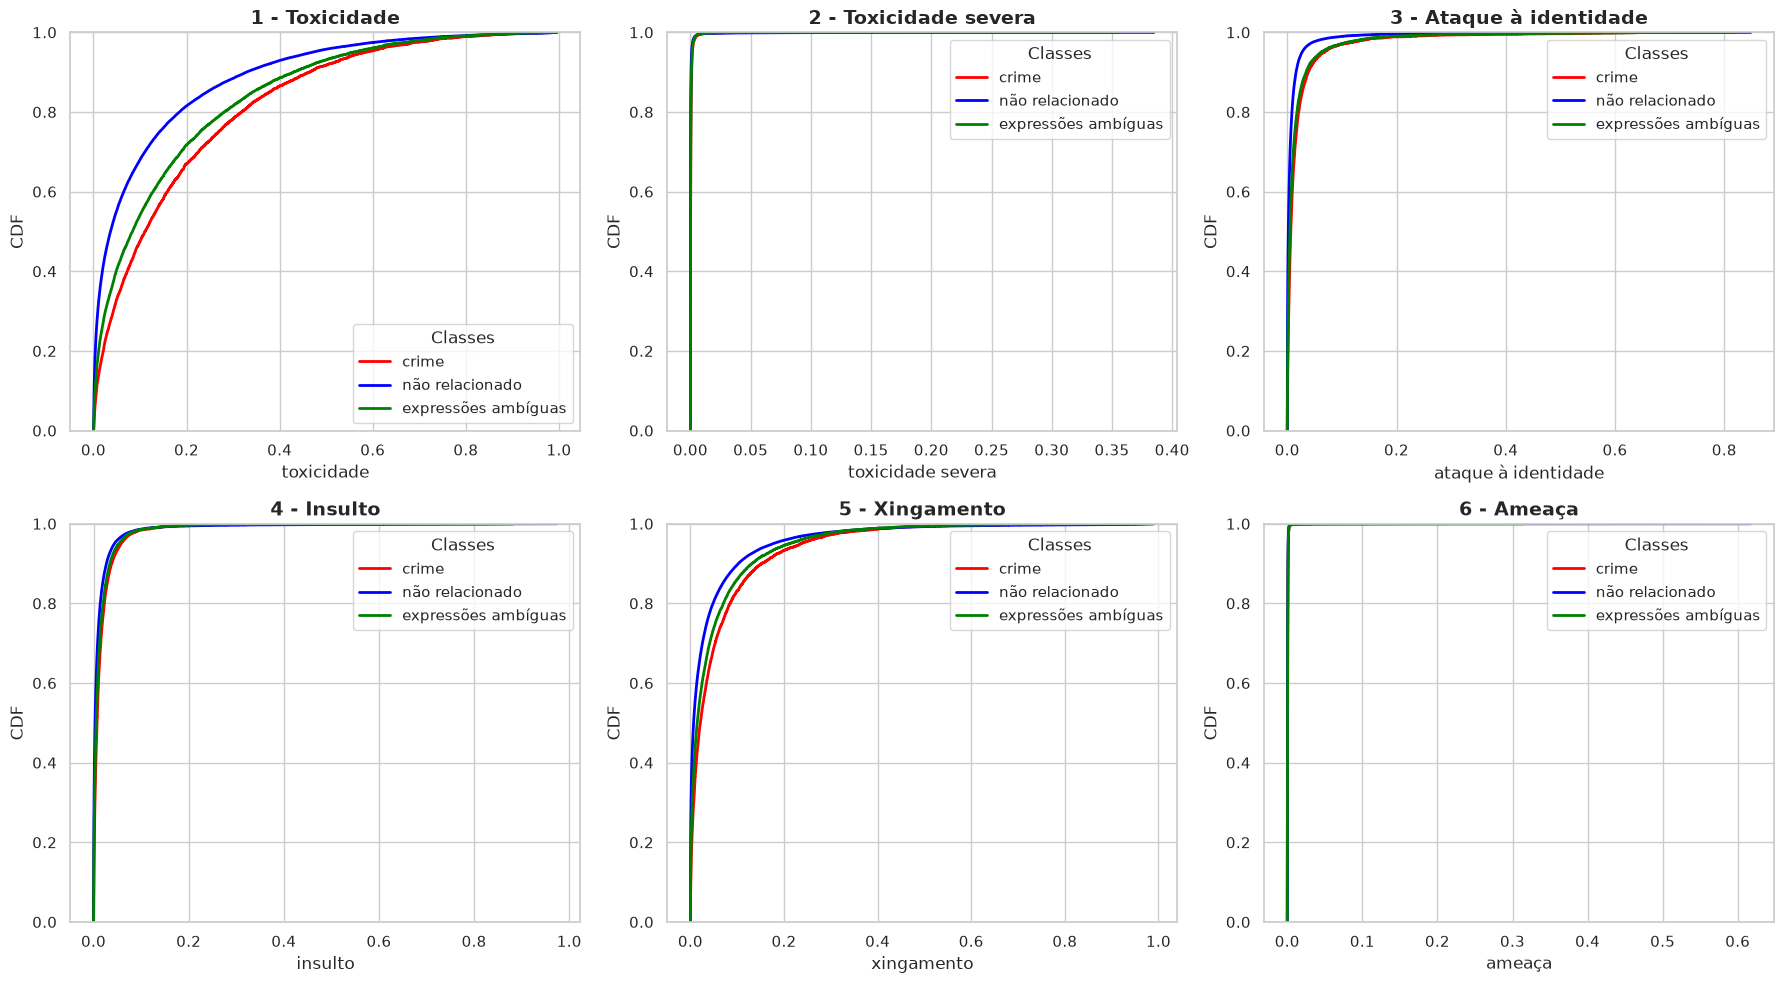

In [28]:
atributos = ['toxicidade','toxicidade severa', 'ataque à identidade', 'insulto', 'xingamento', 'ameaça']
colunas_classes = ['crime', 'não relacionado', 'expressões ambíguas']

cores = ['red', 'blue', 'green'] 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, atributo in enumerate(atributos):

    for j, classe in enumerate(colunas_classes):
        
        subset = toxic[toxic[classe] == 1]

        sns.ecdfplot(
            data=subset, 
            x=atributo, 
            ax=axes[i], 
            label=classe,
            color=cores[j],
            linewidth=2
        )
    
    axes[i].set_title(f'{i+1} - {atributo.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('CDF')
    axes[i].set_xlabel(f'{atributo}')
    axes[i].legend(title="Classes")

plt.tight_layout()
plt.show()

# Plotando original

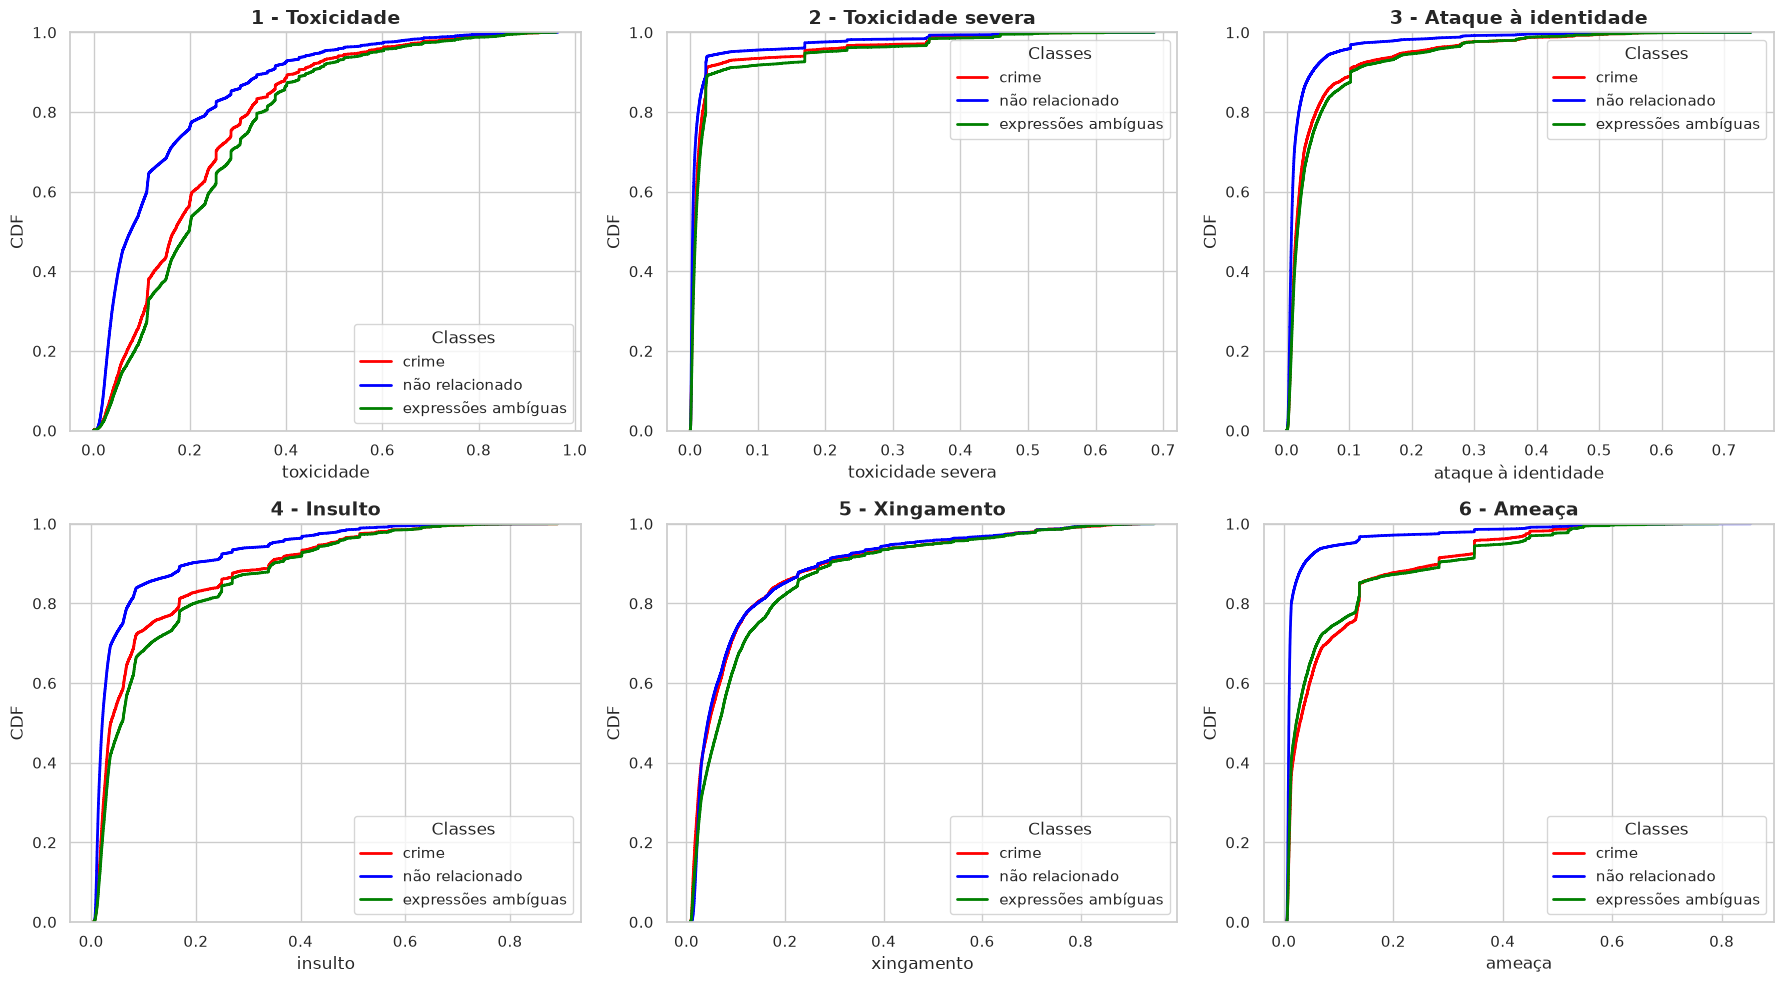

In [29]:
atributos = ['toxicidade','toxicidade severa', 'ataque à identidade', 'insulto', 'xingamento', 'ameaça']
colunas_classes = ['crime', 'não relacionado', 'expressões ambíguas']

cores = ['red', 'blue', 'green'] 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, atributo in enumerate(atributos):

    for j, classe in enumerate(colunas_classes):
        
        subset = crimes[crimes[classe] == 1]

        sns.ecdfplot(
            data=subset, 
            x=atributo, 
            ax=axes[i], 
            label=classe,
            color=cores[j],
            linewidth=2
        )
    
    axes[i].set_title(f'{i+1} - {atributo.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('CDF')
    axes[i].set_xlabel(f'{atributo}')
    axes[i].legend(title="Classes")

plt.tight_layout()
plt.show()